<a href="https://colab.research.google.com/github/JosephBigDataAnalytics/JKaremera-Programming-BigDataAnalytics/blob/main/Task_11_complete_floorplans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tak 11 executive summary

The model iteratively transformed noise into structured architectural layouts, capturing spatial relationships between differnet structures floorplan images

In [ ]:
# Install required libraries
# pip install flow_matching torch torchvision Pillow tqdm einops


load data

In [ ]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm
import numpy as np

# ── Unzip floorplan images ──────────────────────────────────────────────────
ZIP_PATH   = "/content/floorplans_v2-20251223T170650Z-3-001.zip"
EXTRACT_DIR = "./floorplan_data"

os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)
print(f"Extracted to {EXTRACT_DIR}")

# ── Dataset ─────────────────────────────────────────────────────────────────
IMAGE_SIZE = 64   # Increase to 128 if VRAM allows

class FloorplanDataset(Dataset):
    def __init__(self, root_dir, image_size=64):
        self.paths = []
        valid_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tiff"}
        for dp, _, fns in os.walk(root_dir):
            for fn in fns:
                if os.path.splitext(fn)[1].lower() in valid_exts:
                    self.paths.append(os.path.join(dp, fn))

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.Grayscale(num_output_channels=1),  # floorplans are typically grayscale
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])            # scale to [-1, 1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)

dataset = FloorplanDataset(EXTRACT_DIR, IMAGE_SIZE)
print(f"Found {len(dataset)} floorplan images")

dataloader = DataLoader(dataset, batch_size=16, shuffle=True,
                        num_workers=4, pin_memory=True, drop_last=True)


Extracted to ./floorplan_data
Found 1000 floorplan images


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Stage 3 — U-Net Model (Vector Field Network)

In [ ]:
# ── Time-conditioned U-Net for flow matching ─────────────────────────────────

class SinusoidalEmbedding(nn.Module):
    """Encodes scalar time t into a fixed-size embedding."""
    def __init__(self, dim=256):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=device) * (np.log(10000) / (half - 1))
        )
        emb = t[:, None] * freqs[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)   # (B, dim)


class ResBlock(nn.Module):
    def __init__(self, channels, t_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, channels)
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, channels)
        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        h = h + self.t_proj(t_emb)[:, :, None, None]
        h = self.act(self.norm2(h))
        h = self.conv2(h)
        return x + h


class FlowUNet(nn.Module):
    """
    Lightweight U-Net that predicts the velocity field v_t(x)
    given noisy image x_t and time t.
    Input channels = 1 (grayscale), output channels = 1.
    """
    def __init__(self, in_ch=1, base_ch=64, t_dim=256):
        super().__init__()
        self.t_embed = nn.Sequential(
            SinusoidalEmbedding(t_dim),
            nn.Linear(t_dim, t_dim * 4),
            nn.SiLU(),
            nn.Linear(t_dim * 4, t_dim),
        )
        # Encoder
        self.enc1 = nn.Conv2d(in_ch, base_ch, 3, padding=1)
        self.res1 = ResBlock(base_ch, t_dim)
        self.down1 = nn.Conv2d(base_ch, base_ch * 2, 4, stride=2, padding=1)

        self.res2 = ResBlock(base_ch * 2, t_dim)
        self.down2 = nn.Conv2d(base_ch * 2, base_ch * 4, 4, stride=2, padding=1)

        # Bottleneck
        self.mid1 = ResBlock(base_ch * 4, t_dim)
        self.mid2 = ResBlock(base_ch * 4, t_dim)

        # Decoder
        self.up2   = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 4, stride=2, padding=1)
        self.res3  = ResBlock(base_ch * 4, t_dim)   # skip connection doubles channels

        self.up1   = nn.ConvTranspose2d(base_ch * 4, base_ch, 4, stride=2, padding=1)
        self.res4  = ResBlock(base_ch * 2, t_dim)

        self.out   = nn.Conv2d(base_ch * 2, in_ch, 1)

    def forward(self, x_t, t):
        """
        x_t : (B, C, H, W) — interpolated image at time t
        t   : (B,)          — scalar time in [0, 1]
        returns predicted velocity field v_t, same shape as x_t
        """
        t_emb = self.t_embed(t)

        # Encoder
        e1 = self.res1(self.enc1(x_t), t_emb)              # (B, 64, H, W)
        e2 = self.res2(self.down1(e1), t_emb)              # (B,128, H/2, W/2)
        x  = self.down2(e2)                                 # (B,256, H/4, W/4)

        # Bottleneck
        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        # Decoder with skip connections
        x = self.res3(torch.cat([self.up2(x), e2], dim=1), t_emb)
        x = self.res4(torch.cat([self.up1(x), e1], dim=1), t_emb)

        return self.out(x)


trainimg loop

In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS     = 50
LR         = 2e-4
SAVE_EVERY = 10     # save checkpoint every N epochs
SAMPLE_DIR = "./generated_floorplans"
CKPT_PATH  = "./flow_model.pt"

os.makedirs(SAMPLE_DIR, exist_ok=True)

model     = FlowUNet(in_ch=1, base_ch=64).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training on: {DEVICE}")

# ── Training (Optimal Transport Flow Matching) ────────────────────────────────
def train_flow_matching(model, dataloader, optimizer, scheduler, epochs, device):
    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch}/{epochs}")

        for x1 in pbar:
            x1 = x1.to(device)                              # real floorplan images
            B  = x1.size(0)

            # Sample noise x0 ~ N(0, I)
            x0 = torch.randn_like(x1)

            # Sample random time t ~ U[0,1] for each item in batch
            t  = torch.rand(B, device=device)

            # ── Optimal Transport linear interpolation ──
            # x_t = (1 - t)*x0 + t*x1
            t_view = t.view(B, 1, 1, 1)
            x_t    = (1.0 - t_view) * x0 + t_view * x1

            # Target velocity = x1 - x0 (straight-line OT path)
            v_target = x1 - x0

            # Predict velocity field
            v_pred = model(x_t, t)

            # MSE loss between predicted and target velocity
            loss = nn.functional.mse_loss(v_pred, v_target)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        scheduler.step()
        avg_loss = total_loss / len(dataloader)
        print(f"  → Epoch {epoch} | Avg Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

        if epoch % SAVE_EVERY == 0:
            torch.save({"epoch": epoch, "model": model.state_dict(),
                        "optimizer": optimizer.state_dict()}, CKPT_PATH)
            print(f"  ✓ Checkpoint saved: {CKPT_PATH}")

    torch.save({"epoch": epochs, "model": model.state_dict()}, CKPT_PATH)
    print("Training complete.")

train_flow_matching(model, dataloader, optimizer, scheduler, EPOCHS, DEVICE)

Model parameters: 6,457,345
Training on: cuda


Epoch 1/50: 100%|██████████| 62/62 [00:05<00:00, 11.38it/s, loss=0.3543]


  → Epoch 1 | Avg Loss: 0.4246 | LR: 0.000200


Epoch 2/50: 100%|██████████| 62/62 [00:05<00:00, 11.18it/s, loss=0.1916]


  → Epoch 2 | Avg Loss: 0.2397 | LR: 0.000199


...

Epoch 39/50: 100%|██████████| 62/62 [00:05<00:00, 10.62it/s, loss=0.1182]


  → Epoch 39 | Avg Loss: 0.1344 | LR: 0.000023


Epoch 40/50: 100%|██████████| 62/62 [00:05<00:00, 10.59it/s, loss=0.1438]


  → Epoch 40 | Avg Loss: 0.1360 | LR: 0.000019
  ✓ Checkpoint saved: ./flow_model.pt


Epoch 41/50:   2%|▏         | 1/62 [00:00<00:15,  3.85it/s, loss=0.1302]

Stage 5 — Generating Synthetic Floorplans

In [ ]:
# ── Euler ODE Sampler ─────────────────────────────────────────────────────────
@torch.no_grad()
def generate_floorplans(model, n_samples=16, n_steps=100,
                         image_size=64, device="cpu", save_dir="./generated_floorplans"):
    """
    Integrate x_t from t=0 (noise) to t=1 (floorplan) using Euler method.
    x_{t+dt} = x_t + v_theta(x_t, t) * dt
    """
    model.eval()
    os.makedirs(save_dir, exist_ok=True)

    # Start from pure Gaussian noise
    x = torch.randn(n_samples, 1, image_size, image_size, device=device)

    # Time steps from 0 → 1
    ts = torch.linspace(0.0, 1.0, n_steps + 1, device=device)
    dt = ts[1] - ts[0]

    for i in range(n_steps):
        t_batch = ts[i].expand(n_samples)
        v = model(x, t_batch)
        x = x + v * dt   # Euler step

    # Rescale from [-1, 1] to [0, 1] for saving
    x = (x.clamp(-1, 1) + 1) / 2.0

    # Save as grid and individual files
    grid_path = os.path.join(save_dir, "generated_grid.png")
    save_image(x, grid_path, nrow=4, padding=4)
    print(f"Saved grid: {grid_path}")

    for i, img in enumerate(x):
        img_path = os.path.join(save_dir, f"floorplan_{i+1:03d}.png")
        save_image(img, img_path)

    print(f"✓ Generated {n_samples} floorplans → {save_dir}/")
    return x

# Load checkpoint if resuming
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model"])

# Generate 16 synthetic floorplans
generated = generate_floorplans(
    model,
    n_samples=16,
    n_steps=100,
    image_size=IMAGE_SIZE,
    device=DEVICE,
    save_dir=SAMPLE_DIR
)


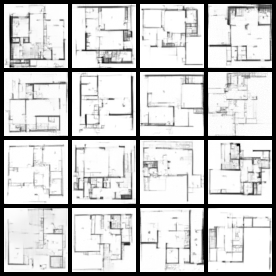

In [ ]:
from IPython.display import Image
import os

Image(os.path.join(SAMPLE_DIR, "generated_grid.png"))